Dataset Shape:
(10000, 14)

First 5 Rows:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0   

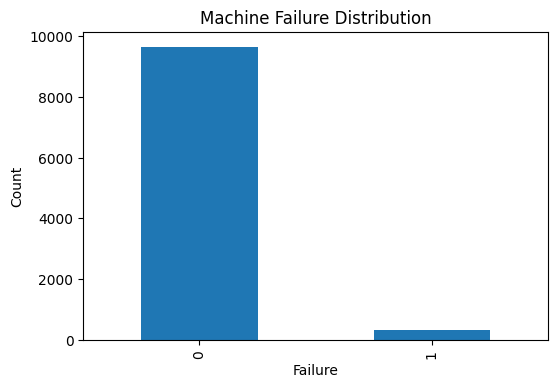

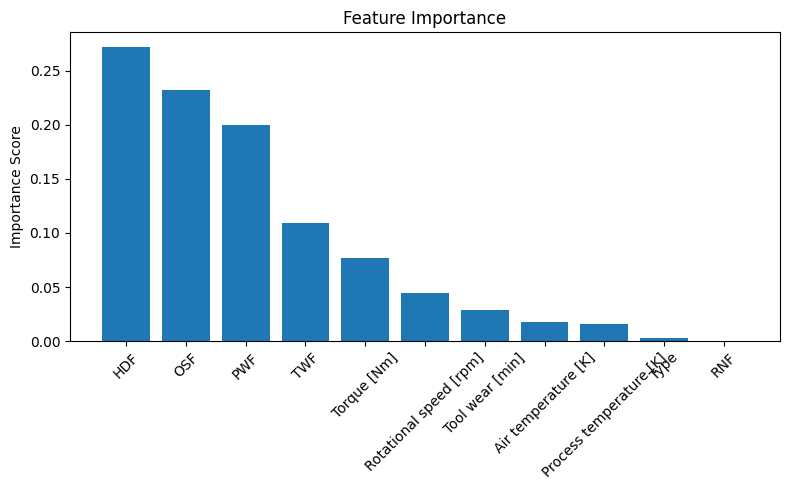

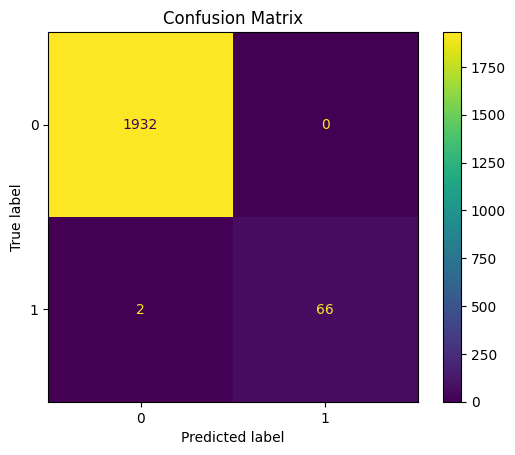

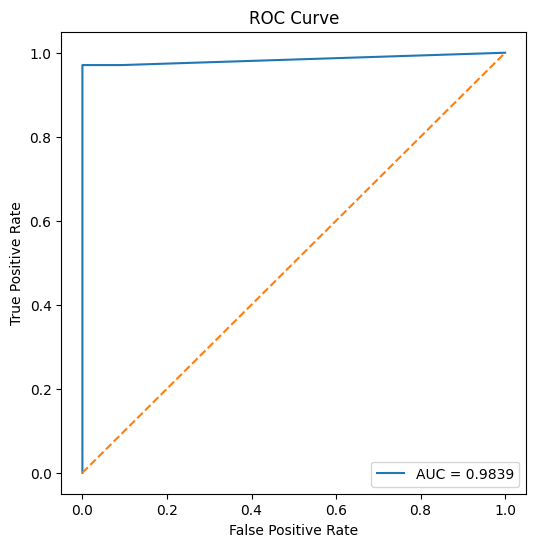


Example Prediction:
      Type  Air temperature [K]  Process temperature [K]  \
2997     1                300.5                    309.8   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  TWF  HDF  PWF  \
2997                    1345         62.7              153    0    0    0   

      OSF  RNF  
2997    0    0  

Predicted Failure: 0
Machine operating normally.

Feature importance saved as: feature_importance.csv


In [2]:
# ============================================================
# AI4I 2020 Predictive Maintenance Dataset
# 数据集自动下载
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# ============================================================
# 自动下载数据集
# ============================================================
import urllib.request
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
filename = "ai4i2020.csv"

if not os.path.exists(filename):
    print("正在自动下载数据集...")
    urllib.request.urlretrieve(url, filename)
    print("下载完成！")

df = pd.read_csv(filename)

print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ============================================================
# 数据预处理
# ============================================================
df = df.drop(columns=["UDI", "Product ID"])
encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])

target = "Machine failure"
X = df.drop(columns=[target])
y = df[target]

print("\nFeature Columns:")
print(X.columns)

# ============================================================
# ✅ 已修复：train_test_split 补全 y
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

# ============================================================
# 训练模型
# ============================================================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ============================================================
# 预测
# ============================================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ============================================================
# 评估
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
print("\n==============================")
print("Model Accuracy:")
print(f"{accuracy:.4f}")
print("==============================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# 可视化
# ============================================================
# 故障分布
plt.figure(figsize=(6,4))
df[target].value_counts().plot(kind='bar')
plt.title("Machine Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")
plt.show()

# 特征重要性
importance = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importance})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(importance_df["Feature"], importance_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ROC 曲线
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 示例预测
# ============================================================
sample = X_test.iloc[[0]]
prediction = model.predict(sample)[0]
print("\nExample Prediction:")
print(sample)
print("\nPredicted Failure:", prediction)
if prediction == 1:
    print("Warning: Potential machine failure detected.")
else:
    print("Machine operating normally.")

# ============================================================
# 保存特征重要性
# ============================================================
importance_df.to_csv("feature_importance.csv", index=False)
print("\nFeature importance saved as: feature_importance.csv")